# Seaborn 绘图练习：参考答案

本文件对应章节最后的绘图练习。每题先保留题目，再给出一种可运行的参考答案。

## 准备工作

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

okabe_ito = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#999999"]
sns.set_theme(style="ticks", context="notebook")
sns.set_palette(okabe_ito)
plt.rcParams["font.sans-serif"] = ["Hiragino Sans GB", "Microsoft YaHei", "WenQuanYi Micro Hei"]
plt.rcParams["axes.unicode_minus"] = False
%config InlineBackend.figure_formats = ["svg"]

In [2]:
annual = pd.read_excel("data/company_visualization_sample.xlsx")
annual["统计截止日期"] = pd.to_datetime(annual["统计截止日期"])
annual["年份"] = annual["统计截止日期"].dt.year
annual["净利率"] = (annual["净利润_亿元"] / annual["营业收入_亿元"]).round(4)
annual["负债水平"] = np.where(annual["资产负债率"] >= 0.6, "较高", "正常")

industry_short = {
    "计算机、通信和其他电子设备制造业": "电子设备",
    "电气机械及器材制造业": "电气设备",
    "医药制造业": "医药",
    "软件和信息技术服务业": "软件服务",
    "汽车制造业": "汽车",
    "房地产业": "房地产",
}
annual["行业简称"] = annual["行业名称"].map(industry_short)
annual_2020 = annual.loc[annual["年份"] == 2020].copy()

annual_2020.head()

,证券代码,股票简称,统计截止日期,年份,行业名称,所属省份,总资产_亿元,营业收入_亿元,净利润_亿元,资产负债率,营业毛利率,员工数目,净利率,负债水平,行业简称
2,403,派林生物,2020-12-31,2020,医药制造业,山西省,16.53,10.50,1.83,0.4149,0.4882,902,0.1743,正常,医药
8,650,仁和药业,2020-12-31,2020,医药制造业,江西省,63.05,41.06,6.58,0.1102,0.4018,6538,0.1603,正常,医药
14,952,广济药业,2020-12-31,2020,医药制造业,湖北省,19.79,6.88,0.70,0.3101,0.4063,1302,0.1017,正常,医药
20,2099,海翔药业,2020-12-31,2020,医药制造业,浙江省,71.79,24.71,3.20,0.1848,0.4542,3282,0.1295,正常,医药
26,2393,力生制药,2020-12-31,2020,医药制造业,天津市,50.22,11.41,0.09,0.1434,0.6148,1691,0.0079,正常,医药


## 阶段 1 练习：分布图

**练习 1.1**：画出 2020 年公司 `净利率` 的直方图。

<Axes: xlabel='净利率', ylabel='Count'>

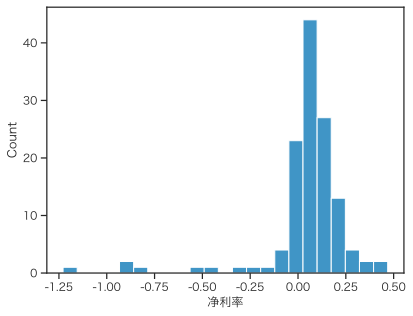

In [3]:
sns.histplot(data=annual_2020, x="净利率")

**练习 1.2**：画出 2020 年 `医药` 和 `汽车` 两个行业 `营业毛利率` 的重叠直方图，并加入 `kde=True`。

In [4]:
margin_compare = annual_2020.loc[annual_2020["行业简称"].isin(["医药", "汽车"])].copy()

margin_compare[["股票简称", "行业简称", "营业毛利率"]].head()

,股票简称,行业简称,营业毛利率
2,派林生物,医药,0.4882
8,仁和药业,医药,0.4018
14,广济药业,医药,0.4063
20,海翔药业,医药,0.4542
26,力生制药,医药,0.6148


<Axes: xlabel='营业毛利率', ylabel='Count'>

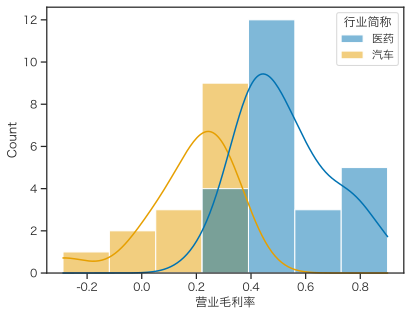

In [5]:
sns.histplot(
    data=margin_compare,
    x="营业毛利率",
    hue="行业简称",
    multiple="layer",
    kde=True,
)

## 阶段 2 练习：类别比较图

**练习 2.1**：画出 2020 年样本公司所属省份数量最多的前 10 个省份的计数图。

In [6]:
top_provinces = annual_2020["所属省份"].value_counts().head(10).index
top_province_data = annual_2020.loc[annual_2020["所属省份"].isin(top_provinces)].copy()

top_province_data["所属省份"].value_counts()

所属省份
广东省    30
浙江省    15
江苏省    13
北京市    12
湖北省     9
上海市     9
四川省     5
湖南省     4
安徽省     3
河南省     3
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='所属省份'>

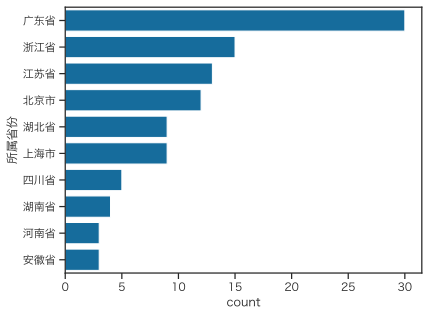

In [7]:
sns.countplot(data=top_province_data, y="所属省份", order=top_provinces)

**练习 2.2**：画出 2020 年不同 `行业简称` 的平均 `资产负债率` 柱状图，行业按平均资产负债率从高到低排列。

In [8]:
debt_by_industry = (
    annual_2020.groupby("行业简称", as_index=False)["资产负债率"]
    .mean()
    .sort_values("资产负债率", ascending=False)
)

debt_by_industry

,行业简称,资产负债率
1,房地产,0.610473
4,电气设备,0.427041
3,电子设备,0.411956
2,汽车,0.389127
5,软件服务,0.377395
0,医药,0.309004


<Axes: xlabel='资产负债率', ylabel='行业简称'>

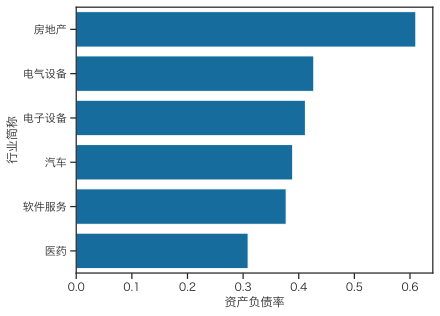

In [9]:
sns.barplot(data=debt_by_industry, y="行业简称", x="资产负债率")

## 阶段 3 练习：散点图

**练习 3.1**：画出 2020 年 `总资产_亿元` 与 `营业收入_亿元` 的原始散点图。

<Axes: xlabel='总资产_亿元', ylabel='营业收入_亿元'>

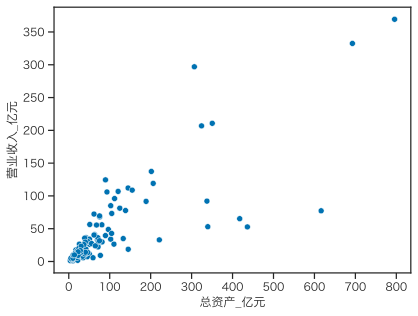

In [10]:
sns.scatterplot(data=annual_2020, x="总资产_亿元", y="营业收入_亿元")

**练习 3.2**：生成 `log_总资产` 和 `log_营业收入`，画出这两个对数变量的散点图。

In [11]:
annual_2020["log_总资产"] = np.log(annual_2020["总资产_亿元"])
annual_2020["log_营业收入"] = np.log(annual_2020["营业收入_亿元"])

annual_2020[["股票简称", "总资产_亿元", "log_总资产", "营业收入_亿元", "log_营业收入"]].head()

,股票简称,总资产_亿元,log_总资产,营业收入_亿元,log_营业收入
2,派林生物,16.53,2.805177,10.50,2.351375
8,仁和药业,63.05,4.143928,41.06,3.715034
14,广济药业,19.79,2.985177,6.88,1.928619
20,海翔药业,71.79,4.273745,24.71,3.207208
26,力生制药,50.22,3.916413,11.41,2.434490


<Axes: xlabel='log_总资产', ylabel='log_营业收入'>

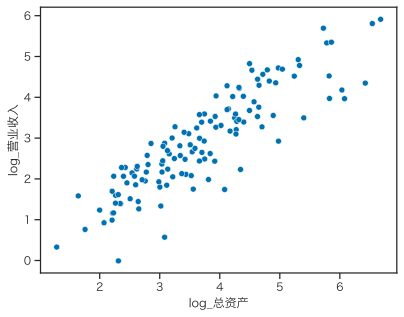

In [12]:
sns.scatterplot(data=annual_2020, x="log_总资产", y="log_营业收入")

## 阶段 4 练习：折线图

**练习 4.1**：按年份计算样本公司的平均 `营业毛利率`，展示汇总表，并画折线图。

In [13]:
gross_margin_year = (
    annual.groupby("年份", as_index=False)
    .agg(平均营业毛利率=("营业毛利率", "mean"))
)

gross_margin_year

,年份,平均营业毛利率
0,2018,0.346703
1,2019,0.341227
2,2020,0.329817
3,2021,0.319843
4,2022,0.302839
5,2023,0.304695


<Axes: xlabel='年份', ylabel='平均营业毛利率'>

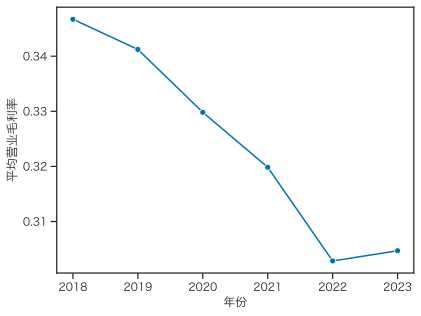

In [14]:
sns.lineplot(data=gross_margin_year, x="年份", y="平均营业毛利率", marker="o")

**练习 4.2**：按 `负债水平` 和年份计算平均 `净利率`，展示汇总表前几行，并画带颜色分组的折线图。

In [15]:
margin_by_debt_year = (
    annual.groupby(["负债水平", "年份"], as_index=False)
    .agg(平均净利率=("净利率", "mean"))
)

margin_by_debt_year.head()

,负债水平,年份,平均净利率
0,正常,2018,0.009700
1,正常,2019,0.047892
2,正常,2020,0.067311
3,正常,2021,0.066494
4,正常,2022,0.050857


<Axes: xlabel='年份', ylabel='平均净利率'>

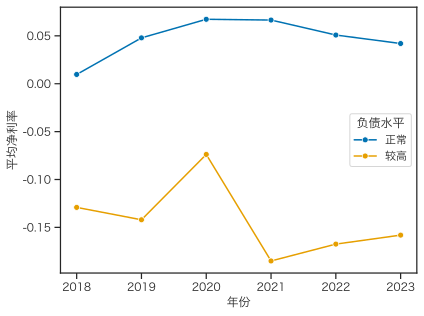

In [16]:
sns.lineplot(data=margin_by_debt_year, x="年份", y="平均净利率", hue="负债水平", marker="o")

## 阶段 5 练习：热力图

**练习 5.1**：制作“行业简称 × 年份”的平均 `资产负债率` 矩阵，并画热力图。

In [17]:
debt_matrix = annual.pivot_table(
    index="行业简称",
    columns="年份",
    values="资产负债率",
    aggfunc="mean",
)

debt_matrix

年份,2018,2019,2020,2021,2022,2023
行业简称,,,,,,
医药,0.317358,0.308300,0.309004,0.302300,0.321233,0.289021
房地产,0.622873,0.607836,0.610473,0.582345,0.580755,0.563509
汽车,0.375727,0.406393,0.389127,0.389913,0.449593,0.435780
电子设备,0.404791,0.409597,0.411956,0.420831,0.431262,0.432569
电气设备,0.393419,0.406385,0.427041,0.429574,0.416289,0.413056
软件服务,0.372842,0.387611,0.377395,0.415668,0.446495,0.435605


<Axes: xlabel='年份', ylabel='行业简称'>

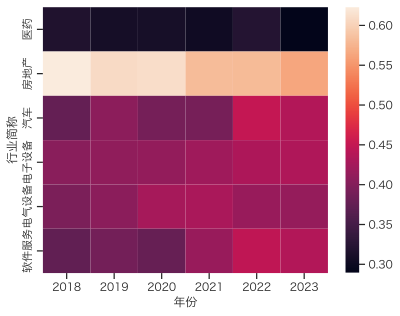

In [18]:
sns.heatmap(debt_matrix)

**练习 5.2**：制作“行业简称 × 年份”的平均 `营业毛利率` 矩阵，并画带数字标注的热力图。

In [19]:
gross_matrix = annual.pivot_table(
    index="行业简称",
    columns="年份",
    values="营业毛利率",
    aggfunc="mean",
)

gross_matrix

年份,2018,2019,2020,2021,2022,2023
行业简称,,,,,,
医药,0.548921,0.550354,0.526725,0.511775,0.480200,0.477963
房地产,0.400900,0.415364,0.351836,0.383036,0.330627,0.331191
汽车,0.239487,0.225413,0.175927,0.205773,0.190393,0.181413
电子设备,0.271325,0.245222,0.270759,0.246753,0.252247,0.244478
电气设备,0.302030,0.305230,0.301337,0.278389,0.263585,0.276281
软件服务,0.334974,0.338426,0.329774,0.312879,0.292479,0.309616


<Axes: xlabel='年份', ylabel='行业简称'>

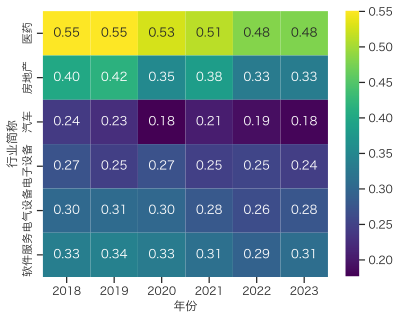

In [20]:
sns.heatmap(gross_matrix, annot=True, fmt=".2f", cmap="viridis")

## 阶段 6 练习：图形整理

**练习 6.1**：整理一张 `资产负债率` 与 `营业毛利率` 的散点图，要求包含标题、坐标轴名称和合适的图例。

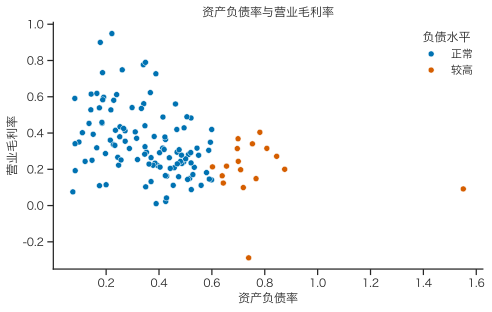

In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(
    data=annual_2020,
    x="资产负债率",
    y="营业毛利率",
    hue="负债水平",
    palette={"正常": "#0072B2", "较高": "#D55E00"},
    ax=ax,
)
ax.set(title="资产负债率与营业毛利率", xlabel="资产负债率", ylabel="营业毛利率")
ax.legend(title="负债水平", frameon=False)
sns.despine()
plt.tight_layout()

**练习 6.2**：使用 `plt.subplots()` 组合两张图：左边画 `营业毛利率` 直方图，右边画 `资产负债率` 箱形图。

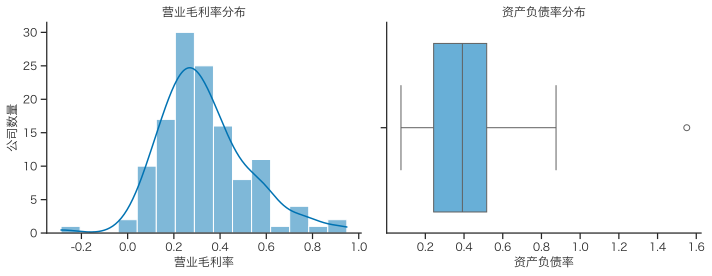

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

sns.histplot(data=annual_2020, x="营业毛利率", kde=True, color="#0072B2", ax=axes[0])
axes[0].set(title="营业毛利率分布", xlabel="营业毛利率", ylabel="公司数量")

sns.boxplot(data=annual_2020, x="资产负债率", color="#56B4E9", ax=axes[1])
axes[1].set(title="资产负债率分布", xlabel="资产负债率")

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()